<a href="https://colab.research.google.com/github/geriiy/PCVK_Ganjil_2025/blob/main/Week5_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# PRAKTIKUM 1

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

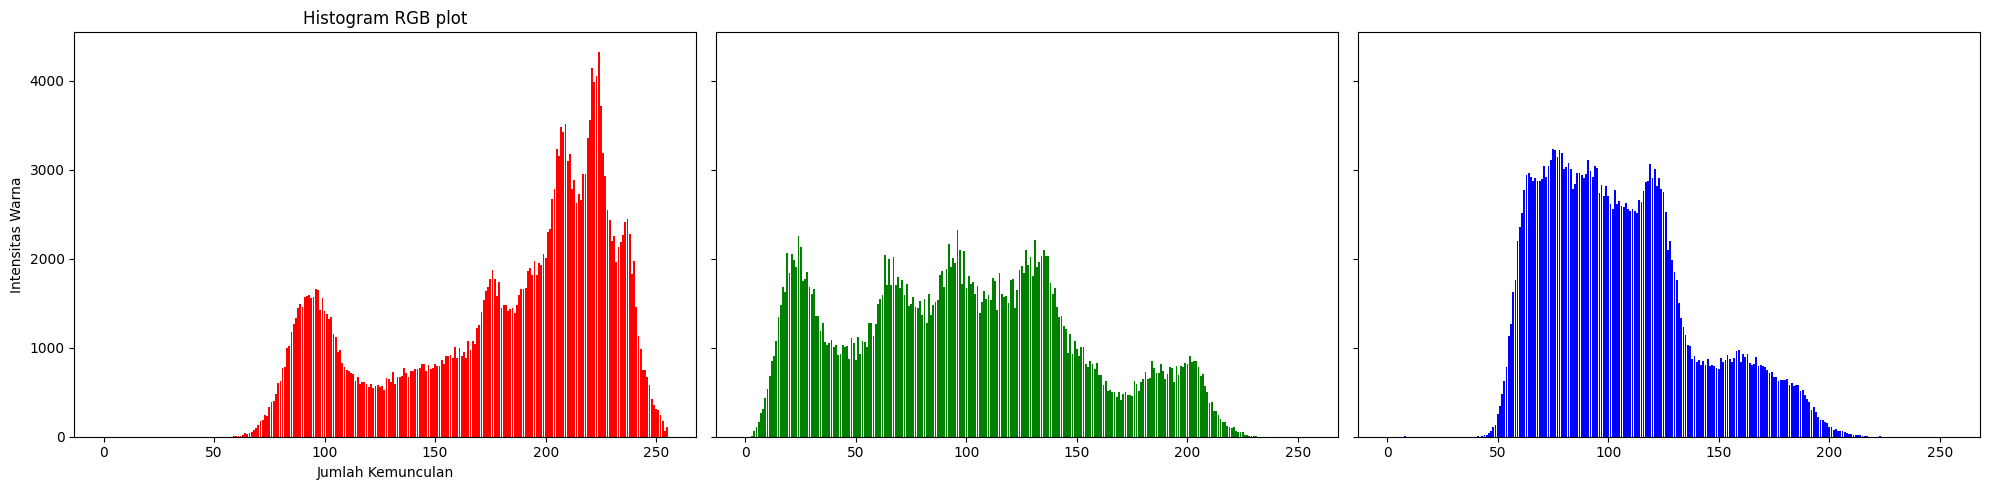

In [4]:
# membuat histogram image (manual)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(height):
    for x in range(width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
axs[0].set_title('Histogram RGB plot')
axs[0].bar(names, red, color='red')
axs[0].set_xlabel('Jumlah Kemunculan', ha='center', rotation='horizontal')
axs[0].set_ylabel('Intensitas Warna', ha='center')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.tight_layout()
plt.show()

# Pertanyaan Praktikum
1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

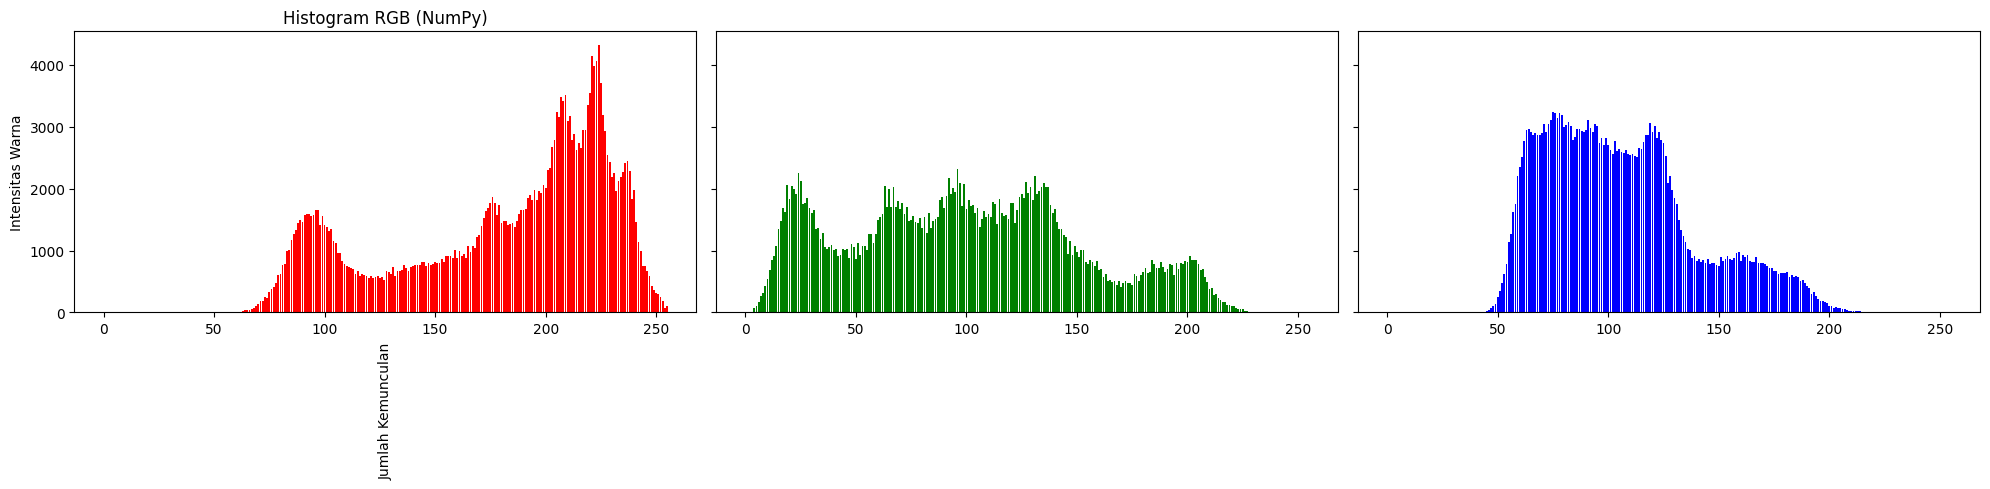

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load dan konversi citra
img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
r_channel = img[:, :, 0].flatten()
g_channel = img[:, :, 1].flatten()
b_channel = img[:, :, 2].flatten()

# Hitung histogram dengan NumPy
red_hist, _ = np.histogram(r_channel, bins=256, range=(0, 256))
green_hist, _ = np.histogram(g_channel, bins=256, range=(0, 256))
blue_hist, _ = np.histogram(b_channel, bins=256, range=(0, 256))

# Plot hasil
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
axs[0].set_title('Histogram RGB (NumPy)')
axs[0].bar(names, red_hist, color='red')
axs[0].set_xlabel('Jumlah Kemunculan', ha='center', rotation='vertical')
axs[0].set_ylabel('Intensitas Warna', ha='center')
axs[1].bar(names, green_hist, color='green')
axs[2].bar(names, blue_hist, color='blue')
plt.tight_layout()
plt.show()

Output histogram-nya akan sama, karena keduanya menghitung jumlah kemunculan intensitas warna dari 0–255. Perbedaannya hanya pada efisiensi dan gaya penulisan.


2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

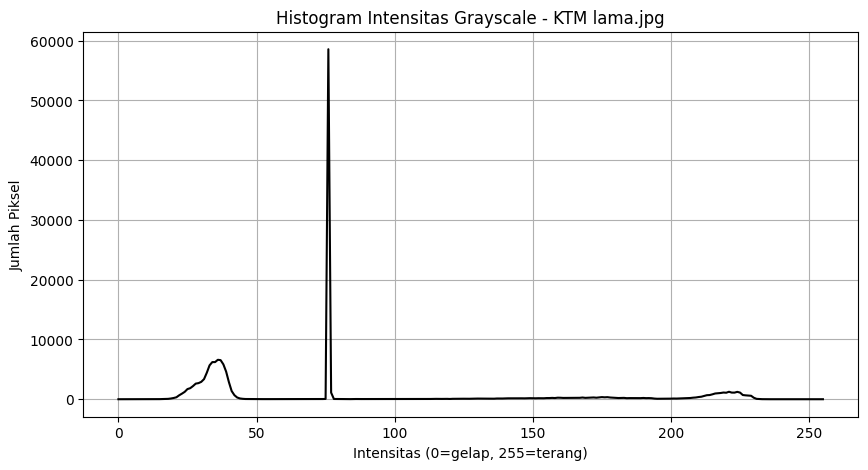

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load citra dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/KTM_lama.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Hitung histogram dengan NumPy
hist, bins = np.histogram(gray.flatten(), bins=256, range=(0, 256))

# Plot histogram
plt.figure(figsize=(10,5))
plt.title('Histogram Intensitas Grayscale - KTM lama.jpg')
plt.xlabel('Intensitas (0=gelap, 255=terang)')
plt.ylabel('Jumlah Piksel')
plt.plot(hist, color='black')
plt.grid(True)
plt.show()

# PRAKTIKUM 2

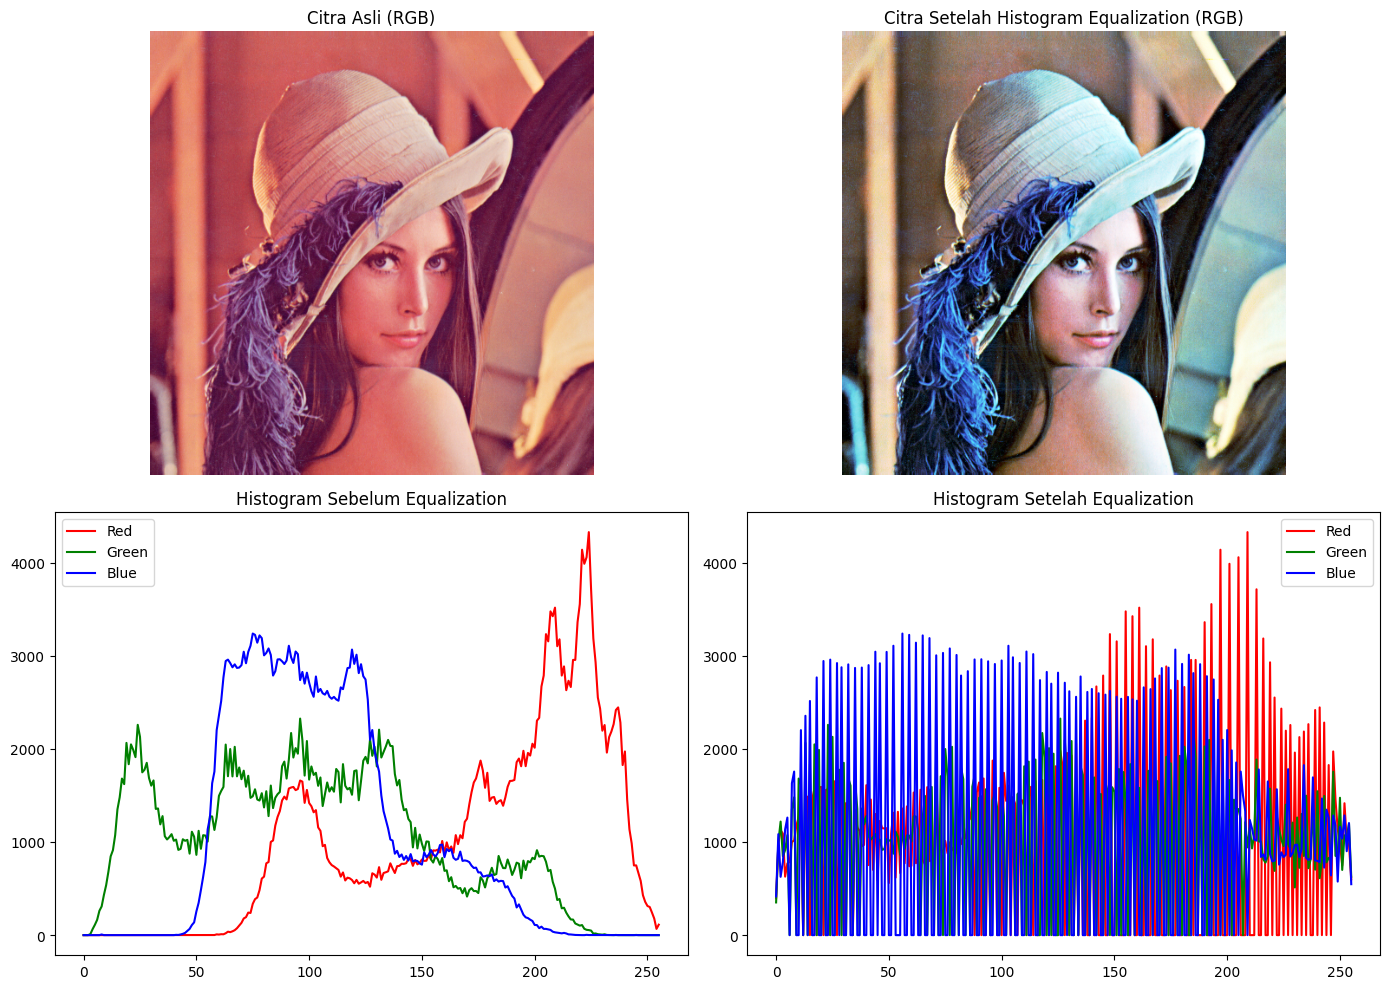

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load citra berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel
r, g, b = cv.split(img_rgb)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Histogram sebelum dan sesudah
r_hist_before, _ = np.histogram(r.flatten(), bins=256, range=(0, 256))
g_hist_before, _ = np.histogram(g.flatten(), bins=256, range=(0, 256))
b_hist_before, _ = np.histogram(b.flatten(), bins=256, range=(0, 256))

r_hist_after, _ = np.histogram(r_eq.flatten(), bins=256, range=(0, 256))
g_hist_after, _ = np.histogram(g_eq.flatten(), bins=256, range=(0, 256))
b_hist_after, _ = np.histogram(b_eq.flatten(), bins=256, range=(0, 256))

# Plot hasil
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Tampilkan citra
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Asli (RGB)')
axs[0, 0].axis('off')

axs[0, 1].imshow(img_eq)
axs[0, 1].set_title('Citra Setelah Histogram Equalization (RGB)')
axs[0, 1].axis('off')

# Histogram sebelum
axs[1, 0].plot(r_hist_before, color='red', label='Red')
axs[1, 0].plot(g_hist_before, color='green', label='Green')
axs[1, 0].plot(b_hist_before, color='blue', label='Blue')
axs[1, 0].set_title('Histogram Sebelum Equalization')
axs[1, 0].legend()

# Histogram sesudah
axs[1, 1].plot(r_hist_after, color='red', label='Red')
axs[1, 1].plot(g_hist_after, color='green', label='Green')
axs[1, 1].plot(b_hist_after, color='blue', label='Blue')
axs[1, 1].set_title('Histogram Setelah Equalization')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”


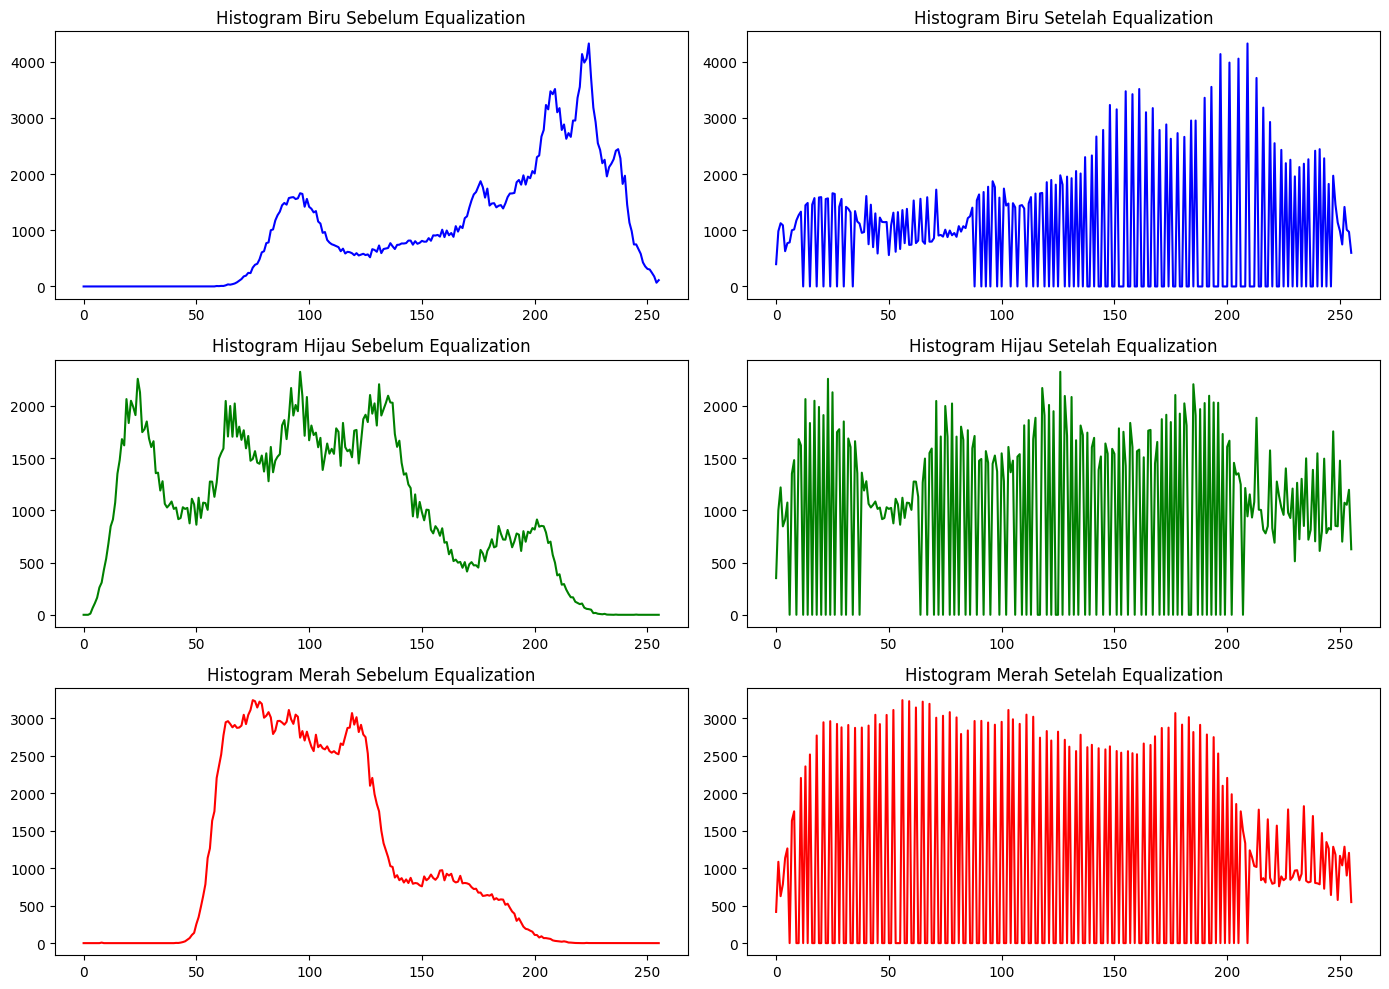

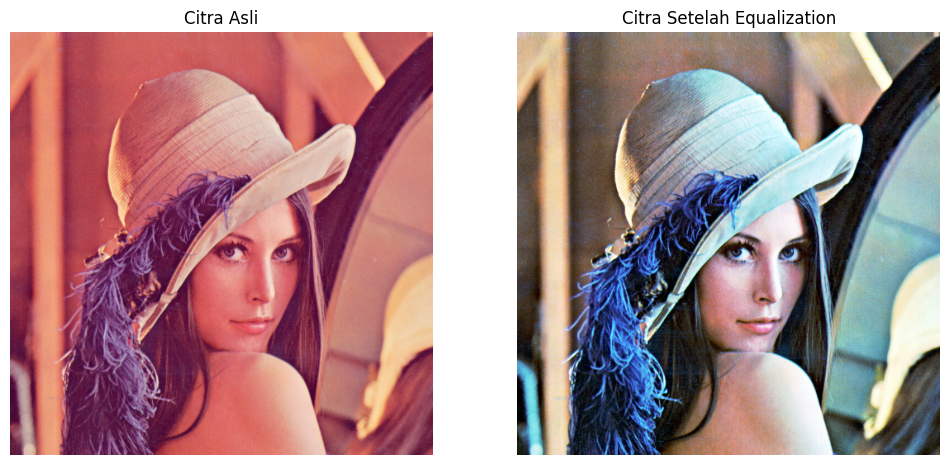

In [9]:
# Load citra berwarna
image = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Split channel
b, g, r = cv.split(image_rgb)

# Equalization per channel
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

# Gabungkan kembali
image_eq = cv.merge((b_equalized, g_equalized, r_equalized))

# Histogram sebelum dan sesudah
def get_histogram(channel):
    return np.histogram(channel.flatten(), bins=256, range=(0, 256))[0]

b_hist_before = get_histogram(b)
g_hist_before = get_histogram(g)
r_hist_before = get_histogram(r)

b_hist_after = get_histogram(b_equalized)
g_hist_after = get_histogram(g_equalized)
r_hist_after = get_histogram(r_equalized)

# Plot hasil
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Histogram sebelum
axs[0, 0].plot(b_hist_before, color='blue')
axs[0, 0].set_title('Histogram Biru Sebelum Equalization')
axs[1, 0].plot(g_hist_before, color='green')
axs[1, 0].set_title('Histogram Hijau Sebelum Equalization')
axs[2, 0].plot(r_hist_before, color='red')
axs[2, 0].set_title('Histogram Merah Sebelum Equalization')

# Histogram sesudah
axs[0, 1].plot(b_hist_after, color='blue')
axs[0, 1].set_title('Histogram Biru Setelah Equalization')
axs[1, 1].plot(g_hist_after, color='green')
axs[1, 1].set_title('Histogram Hijau Setelah Equalization')
axs[2, 1].plot(r_hist_after, color='red')
axs[2, 1].set_title('Histogram Merah Setelah Equalization')

plt.tight_layout()
plt.show()

# Tampilkan citra asli dan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_eq)
plt.title('Citra Setelah Equalization')
plt.axis('off')
plt.show()

Output tidak sama, karena equalizeHist() mengubah distribusi intensitas tiap channel. Hasilnya adalah peningkatan kontras, tapi bisa mengubah tone warna jika tidak hati-hati.


# Pertanyaan Praktikum 2
1. Perbandingan Citra Lena

a. Gunakan hasil histogram equalization pada citra lena.jpg.

b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
visual citra? Apakah ada detail baru yang muncul setelah equalization?

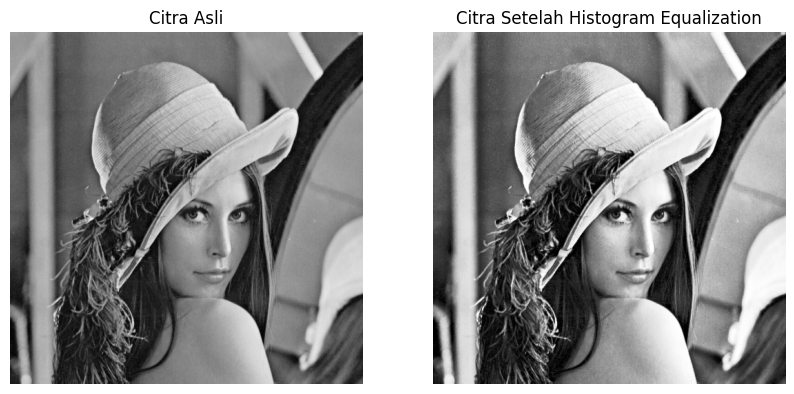

In [10]:
# a. Gunakan hasil histogram equalization pada citra lena.jpg.
# Load citra dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Histogram Equalization
equalized = cv.equalizeHist(gray)

# Tampilkan citra
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title('Citra Setelah Histogram Equalization')
plt.axis('off')
plt.show()

In [11]:
# b. Hitung nilai PSNR antara citra asli dan citra hasil equalization. Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi
def calculate_psnr(original, processed):
    mse = np.mean((original - processed) ** 2)
    if mse == 0:
        return float('inf')  # citra identik
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

psnr_value = calculate_psnr(gray, equalized)
print(f"Nilai PSNR: {psnr_value:.2f} dB")

Nilai PSNR: 27.67 dB


c. Analisis Nilai PSNR dan Kualitas Visual
- Nilai PSNR tinggi (>30 dB) → Perubahan kecil, kualitas visual tetap baik
- Nilai PSNR sedang (20–30 dB) → Ada perubahan visual, tapi masih bisa diterima
- Nilai PSNR rendah (<20 dB) → Perubahan signifikan, kemungkinan detail berubah
- Histogram Equalization mengubah distribusi intensitas, sehingga PSNR akan berkurang karena citra tidak identik lagi.
- Meski PSNR menurun, kualitas visual bisa meningkat karena kontras lebih tajam.
- Detail baru bisa muncul, terutama di area gelap atau terang yang sebelumnya tidak terlihat jelas.


2. Gunakan Citra KTM Lama.jpg

a. Terapkan histogram equalization pada citra KTM lama.jpg.

b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
dalam satu layout.

c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

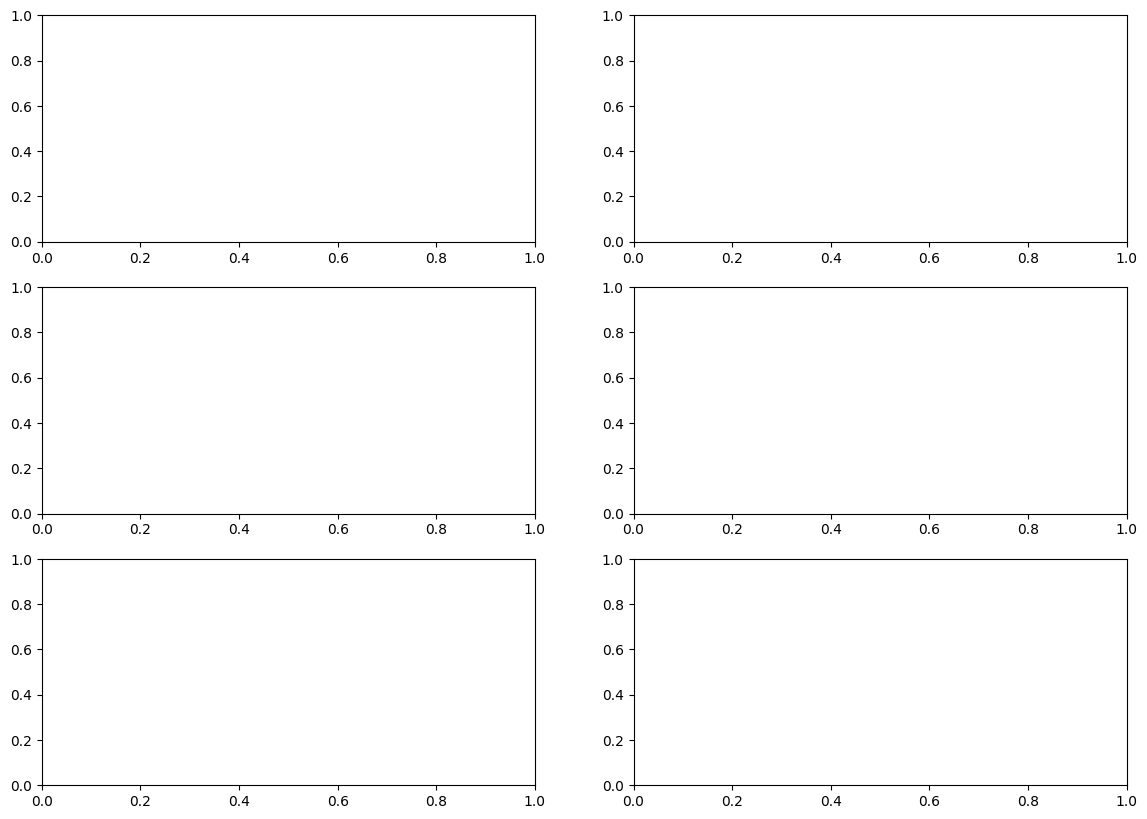

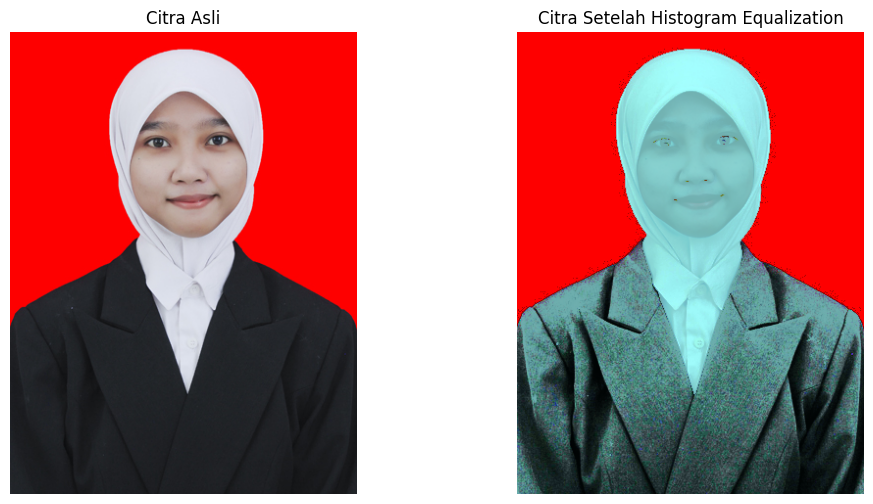

<Figure size 640x480 with 0 Axes>

In [12]:
# Load citra dan konversi ke RGB
img = cv.imread('/content/drive/MyDrive/PCVK/KTM_lama.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel
r, g, b = cv.split(img_rgb)

# Equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Gabungkan kembali
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Fungsi histogram
def get_hist(channel):
    return np.histogram(channel.flatten(), bins=256, range=(0, 256))[0]

# Histogram sebelum
r_hist_before = get_hist(r)
g_hist_before = get_hist(g)
b_hist_before = get_hist(b)

# Histogram sesudah
r_hist_after = get_hist(r_eq)
g_hist_after = get_hist(g_eq)
b_hist_after = get_hist(b_eq)

# Plot layout
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Citra asli dan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_eq)
plt.title('Citra Setelah Histogram Equalization')
plt.axis('off')
plt.show()

# Histogram RGB sebelum
axs[0, 0].plot(r_hist_before, color='red')
axs[0, 0].set_title('Red Sebelum')
axs[1, 0].plot(g_hist_before, color='green')
axs[1, 0].set_title('Green Sebelum')
axs[2, 0].plot(b_hist_before, color='blue')
axs[2, 0].set_title('Blue Sebelum')

# Histogram RGB sesudah
axs[0, 1].plot(r_hist_after, color='red')
axs[0, 1].set_title('Red Setelah')
axs[1, 1].plot(g_hist_after, color='green')
axs[1, 1].set_title('Green Setelah')
axs[2, 1].plot(b_hist_after, color='blue')
axs[2, 1].set_title('Blue Setelah')

plt.tight_layout()
plt.show()

- Histogram Equalization meningkatkan kontras, membuat detail visual lebih jelas.
- Namun, jika dilakukan per channel RGB, warna bisa tampak terlalu “keras” atau tidak natural, terutama jika distribusi awal tiap channel sangat berbeda.


# PRAKTIKUM 3

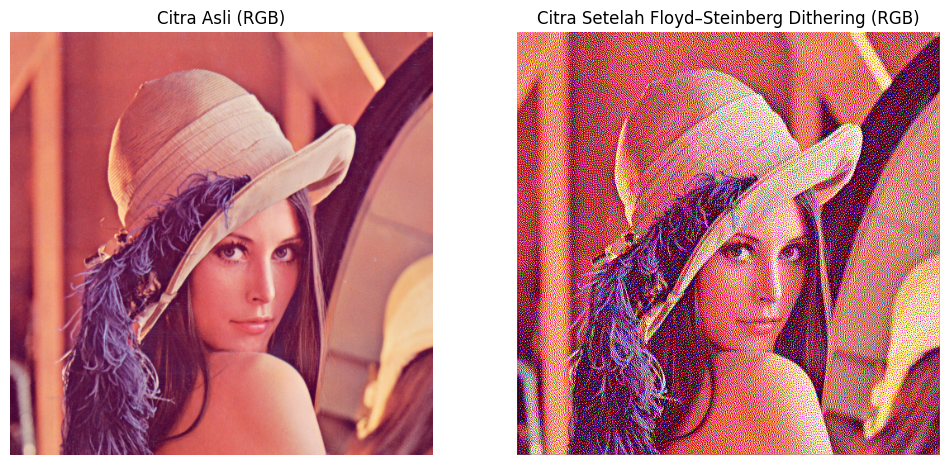

In [14]:
# Load citra berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_rgb = img_rgb.astype(np.float32)

# Siapkan array hasil
dithered = img_rgb.copy()
height, width, _ = dithered.shape

# Terapkan dithering per channel
for y in range(height - 1):
    for x in range(1, width - 1):
        for c in range(3):  # 0=R, 1=G, 2=B
            old_pixel = dithered[y, x, c]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x, c] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error ke tetangga
            dithered[y, x + 1, c]     += error * 7 / 16
            dithered[y + 1, x - 1, c] += error * 3 / 16
            dithered[y + 1, x, c]     += error * 5 / 16
            dithered[y + 1, x + 1, c] += error * 1 / 16

# Konversi ke uint8
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb.astype(np.uint8))
plt.title('Citra Asli (RGB)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dithered)
plt.title('Citra Setelah Floyd–Steinberg Dithering (RGB)')
plt.axis('off')
plt.show()

2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

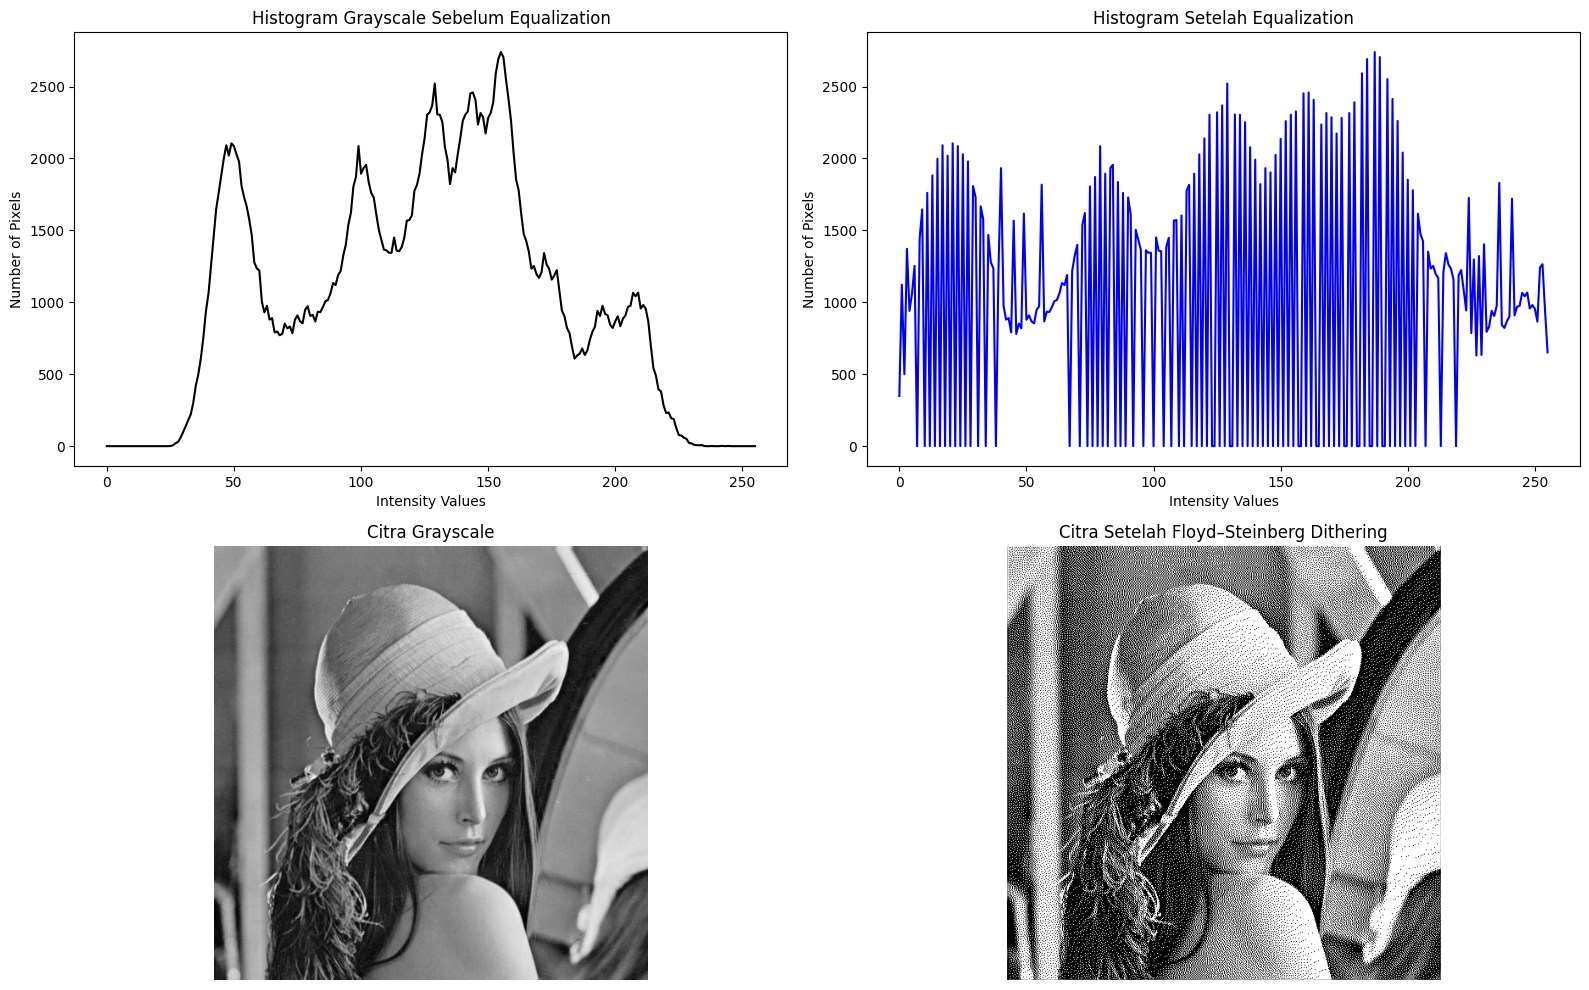

In [20]:
# Load citra dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Histogram sebelum equalization
hist_before, _ = np.histogram(gray.flatten(), bins=256, range=(0, 256))

# Histogram Equalization
equalized = cv.equalizeHist(gray)

# Histogram setelah equalization
hist_after, _ = np.histogram(equalized.flatten(), bins=256, range=(0, 256))

# Floyd–Steinberg Dithering
height, width = equalized.shape
dithered = equalized.astype(np.float32)

for y in range(height - 1):
    for x in range(1, width - 1):
        old_pixel = dithered[y, x]
        new_pixel = 0 if old_pixel < 128 else 255
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        dithered[y, x + 1]     += error * 7 / 16
        dithered[y + 1, x - 1] += error * 3 / 16
        dithered[y + 1, x]     += error * 5 / 16
        dithered[y + 1, x + 1] += error * 1 / 16

dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Layout visualisasi
fig = plt.figure(figsize=(16, 10))

# Histogram sebelum
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(hist_before, color='black')
ax1.set_title('Histogram Grayscale Sebelum Equalization')
ax1.set_xlabel('Intensity Values')
ax1.set_ylabel('Number of Pixels')

# Histogram setelah
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(hist_after, color='blue')
ax2.set_title('Histogram Setelah Equalization')
ax2.set_xlabel('Intensity Values')
ax2.set_ylabel('Number of Pixels')

# Citra grayscale
ax3 = fig.add_subplot(2, 2, 3)
ax3.imshow(gray, cmap='gray')
ax3.set_title('Citra Grayscale')
ax3.axis('off')

# Citra dithering
ax4 = fig.add_subplot(2, 2, 4)
ax4.imshow(dithered, cmap='gray')
ax4.set_title('Citra Setelah Floyd–Steinberg Dithering')
ax4.axis('off')

plt.tight_layout()
plt.show()